# Reinforcement Learning Tarea 3 - Métodos Monte Carlo (blackjack)

En este laboratorio vamos a explorar los métodos de Monte Carlo (Capítulo 5 del libro de Sutton y Barto). Para esto, vamos a volver a utilizar un ambiente definido en [Gymnasium](https://gymnasium.farama.org/index.html), es el caso esta vez de otro ambiente sencillo: el juego de Blackjack. El [ambiente de gymnasium](https://gymnasium.farama.org/environments/toy_text/blackjack/) esta inspirado por el ejemplo 5.1 del libro, ya esta incluido en gym, por lo que no es necesario crearlo desde cero. 


## Descripción del ambiente a usar

### Reglas del juego

Es un juego de cartas donde el objetivo es obtener cartas que sumen lo más cercano a 21 posible, sin pasarnos. Jugamos contra un dealer fijo unicamente.

Reglas:
   
- Las cartas con figuras (Jotas, Reinas y Reyes) tienen valor de 10.
- Los Ases pueden valer 11 ó 1, cuando vale 11 se lo llama "usable" y es su valor por defecto.
- En este caso jugamos con un mazo infinito (con reemplazo).
- El dealer comienza con una carta boca arriba y una boca abajo.
- El jugador puede pedir una carta (HIT) hasta que decida quedarse (STICK) o exceeda los 21 puntos (BUST).
- Cuando el jugador se queda (STICK), el dealer muestra su carta boca abajo y pide cartas hasta que su suma sea 17 o más.
- Si el dealer se pasa de 21, el jugador gana. En caso contrario, gana quien tenga la suma más cerca de 21.

### Implementación en Gymnasium

- La reward por perder es -1, por ganar es +1 y por pedir carta es 0. En caso de empate, la reward es 0.
- Cada observacion es una tupla que tiene: 
    - la suma del jugador
    - la carta boca arriba del dealer (1-10 donde 1 es un As)
    - True o False si el jugador tiene un As usable o no

Revisa el [ambiente en gymnasium](https://gymnasium.farama.org/environments/toy_text/blackjack/) para entender como funciona.


### A entregar

- Notebook con solución a los algoritmos presentados
- Analisis de la función de valor estimada para distinto número de episodios a visitar (ej: 100, 10000, 50000, 500000). Se busca que puedan demostrar entendimiento del algoritmo y sus resultados (Esperamos gráficas y analisis de las mismas). 
- Estimaciones de función de valor para otras politicas definidas por el estudiante (al menos una). 

In [1]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from Utils import plot_value_distribution, plot_Q_distribution, plot_greedy_policy

In [2]:
NUMBER_EPISODES = 500_000

In [3]:
# Nos asegurams que las gráficas se muestren en el notebook
import matplotlib
%matplotlib inline

 Vemos el espacio de estado y acción del ambiente de blackjack.

In [4]:
# Crear el entorno de Blackjack
env = gym.make("Blackjack-v1", render_mode="rgb_array", sab=True)
print(env.action_space)
print(env.observation_space)

Discrete(2)
Tuple(Discrete(32), Discrete(11), Discrete(2))


In [5]:
# vemos un ejemplo de observación
obs, _ = env.reset()
print(f"Jugador: {obs[0]}, Dealer: {obs[1]}, As usable: {obs[2]} ")

Jugador: 14, Dealer: 3, As usable: 0 


Simulemos una partida de blackjack.

In [ ]:
# Caso de prueba
state,_ = env.reset()
print('initial state:', state)

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print('state:', state, 'reward:', reward, 'done:', done)
    if done or truncated:
        print(f'Reward: {reward}')                
        break

initial state: (20, 10, 0)
state: (20, 10, 0) reward: -1.0 done: True
Reward: -1.0


## Predicción de la función de valor ($V$ y $Q$)

Vamos a implementar el algoritmo de Monte Carlo para estimar las funciones de valor $V$ y $Q$ para el ambiente de blackjack asi como algunas variantes (first visit, every visit, exploración inicial, etc).

Para ello primero vamos a definir una politica: Si suma 20 o más, se queda (STICK), si no pide carta (HIT). Esta política es la que se usa en el ejemplo del libro.

In [ ]:
STICK = 0
HIT = 1
       
## Politica Sutton & Barto
def sutton_policy(observation):
    player_sum, _, _ = observation
    return STICK if player_sum >= 20 else HIT

### Generación de episodios

Vamos a implementar una función que genere episodios de la política definida. La función va a recibir el ambiente y la política y va a devolver una lista de transiciones (estado, acción, reward, next_state).

In [ ]:
def generate_episode(policy, env):
    """
    Genera un episodio utilizando la política dada.
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno de OpenAI Gym.
    Returns:
        episode: Lista de tuplas (estado, acción, recompensa, siguiente_estado).
    """
    episode = []
    state, _ = env.reset()
    done = False

    while not done:
        action = policy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward, next_state))
        state = next_state
        done = terminated or truncated

    return episode

In [9]:
# lo probamos
episode = generate_episode(sutton_policy, env)
print("Episodio generado:")
for state, action, reward, next_state in episode:
    print(f"Estado: {state}, Acción: {action} ({'Hit' if action == 1 else 'Stick'}), Recompensa: {reward}, Siguiente estado: {next_state}")

Episodio generado:
Estado: (20, 10, 0), Acción: 0 (Stick), Recompensa: 0.0, Siguiente estado: (20, 10, 0)


### First-Visit MC para estimar $V$

El primer algoritmo que vamos a implementar es el de Monte Carlo First Visit. Este algoritmo estima la función de valor $V$ para una política dada.

$$
\begin{aligned}
\textbf{Algoritmo First-Visit MC (para estimar }v_\pi\text{):} \\[6pt]
\textbf{Entrada:} & \quad \pi,\ \text{política a evaluar.}\\
& \quad \text{(Se asume que podemos generar episodios con } \pi\text{.)}\\[6pt]
\textbf{Inicializar:} 
& \quad V(s) \in \mathbb{R}, \quad \forall\, s \in S \quad (\text{valores arbitrarios})\\
& \quad \text{Returns}(s) \leftarrow \varnothing, \quad \forall\, s \in S.\\[6pt]
\textbf{Bucle (por cada episodio):} 
& \\[-2pt]
& \quad \text{Generar un episodio siguiendo } \pi: (S_0, A_0, R_1, \ldots, S_T).\\
& \quad G \leftarrow 0.\\
& \quad \textbf{para } t = T-1,\, T-2,\, \ldots,\, 0:\\
& \quad\quad G \leftarrow \gamma\,G + R_{t+1}.\\
& \quad\quad \textbf{si } S_t \notin \{S_0, S_1, \ldots, S_{t-1}\}:\\
& \quad\quad\quad \text{Returns}(S_t) \leftarrow \text{Returns}(S_t) \cup \{G\}.\\
& \quad\quad\quad V(S_t) \leftarrow \text{average}\bigl(\text{Returns}(S_t)\bigr).\\[6pt]
\textbf{Retornar:} 
& \quad V.
\end{aligned}
$$

> Tip: con [defaultdict](https://docs.python.org/3/library/collections.html#defaultdict-objects) podemos definir un diccionario con un valor por defecto.

In [10]:
A = defaultdict(float)
B = defaultdict(int)
C = defaultdict(lambda: [])

print(A[999])
print(B[999])
print(C[999])

0.0
0
[]


In [11]:
for i in range(10, -1, -1):
    print(i)

10
9
8
7
6
5
4
3
2
1
0


In [ ]:
from email.policy import default

from numpy import number


def first_visit_mc_prediction(policy, env, number_episodes=NUMBER_EPISODES, gamma=1.0):
    """
    Estima V_pi usando el método de Monte Carlo First-Visit.
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno de OpenAI Gym.
        number_episodes: Cantidad de episodios a generar.
        gamma: Factor de descuento.
    Returns:
        V: defaultdict que mapea estado -> valor estimado V(s).
    """
    
    V = defaultdict(float)
    #returns = defaultdict(lambda: [])
    N = defaultdict(int)
    for _ in tqdm(range(number_episodes)):
        episodio = generate_episode(policy, env)
        state = [s for (s,_,_,_) in episodio]
        G = 0
        T = len(episodio)
        for t in range(T-1, -1, -1):
            s, a, r, s_next = episodio[t] #state, action, reward, state_next
            G = gamma * G + r
            if s not in state[:t]:
                #returns[s].append(G)
                #V[s] = sum(returns[s]) / len(returns[s])
                N[s] += 1
                V[s] += (G - V[s]) / N[s]
    return V
    
    #raise NotImplementedError("Implementar First-Visit MC para estimar V")

In [13]:
sab_value = first_visit_mc_prediction(sutton_policy, env)

100%|██████████| 500000/500000 [00:18<00:00, 27205.74it/s]


In [14]:
print(sab_value)

defaultdict(<class 'float'>, {(21, 4, 1): 0.9756097560975612, (17, 2, 0): -0.6993980436418327, (16, 2, 0): -0.6588749524895451, (21, 10, 0): 0.8911811231215419, (14, 10, 0): -0.6227076035442037, (18, 10, 0): -0.7243511664948977, (16, 10, 0): -0.6758845256609729, (20, 2, 0): 0.6473442976543528, (20, 10, 0): 0.4313666965144405, (19, 4, 0): -0.7392715470609454, (9, 4, 0): -0.497830130192189, (20, 5, 0): 0.6756074890452792, (10, 5, 0): -0.12459194776931427, (20, 10, 1): 0.43022035676810216, (16, 10, 1): -0.39282803585981996, (15, 10, 1): -0.3417172593235037, (12, 10, 1): -0.2525366403607669, (12, 10, 0): -0.5686317521250348, (16, 7, 0): -0.6559535333978712, (15, 7, 0): -0.6371174728529094, (14, 5, 0): -0.6246441642944297, (20, 3, 0): 0.6552411319250688, (18, 4, 0): -0.703162567042722, (13, 4, 0): -0.559764309764309, (15, 10, 0): -0.6550148159308901, (21, 10, 1): 0.916164499418544, (18, 5, 0): -0.7392632524708032, (19, 5, 1): -0.5104408352668213, (17, 1, 0): -0.749953034003382, (10, 1, 0): 

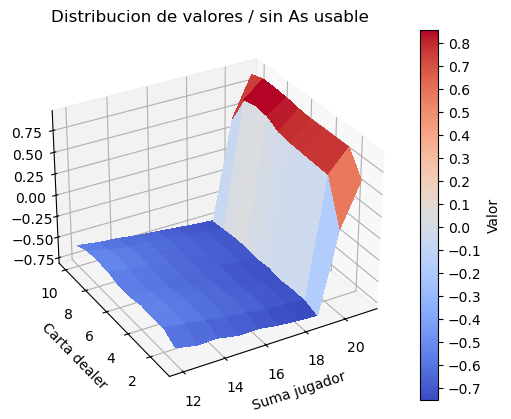

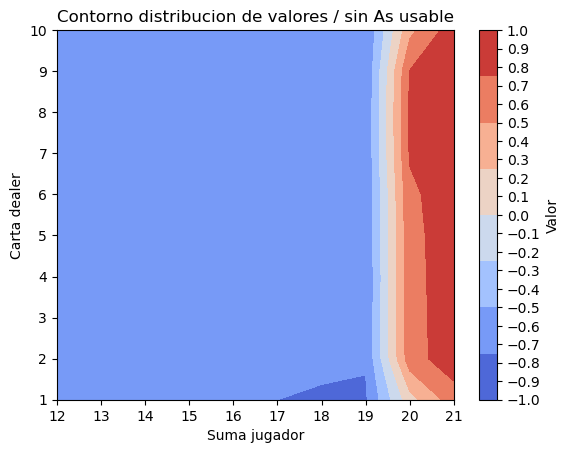

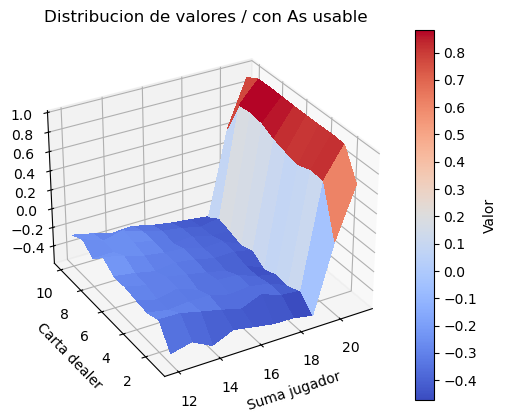

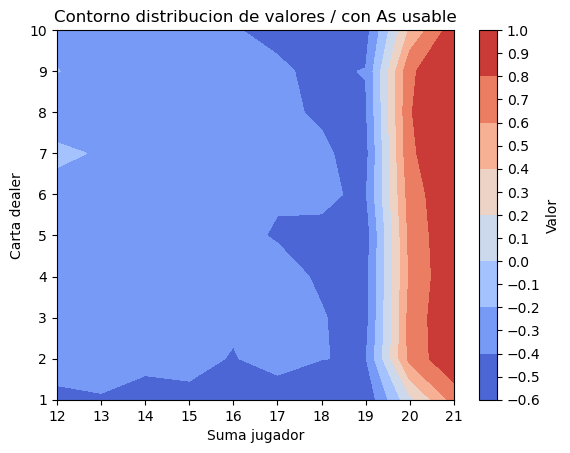

In [15]:
plot_value_distribution(sab_value)

### Convergencia y número de episodios

Por la **ley de los grandes números**, $V(s) \to v_\pi(s)$ cuando el número de visitas a $s$ tiende a infinito. Pero ¿cuántos episodios necesitamos en la práctica?

Una buena forma de inspeccionar la convergencia es comparar la estimación con distintos presupuestos de episodios y observar:
1. **Suavidad** del surface plot (con pocos episodios suele verse muy ruidoso, sobre todo en las regiones con As usable que se visitan menos).
2. **Trayectoria de un estado fijo**, por ejemplo $V((20,5,0))$: graficar su valor estimado vs. el número de episodios y ver cómo decrece la varianza.

Sugerencia para la Tarea 2:
```python
for n in [100, 10_000, 50_000, 500_000]:
    V_n = first_visit_mc_prediction(sutton_policy, env, number_episodes=n)
    plot_value_distribution(V_n)
```
Y/o medir el error contra una estimación de referencia (por ejemplo, $V$ con 1M de episodios).

Una estrategía más elaborada, basada en Edward Thorp, que se basa en la carta del dealer y la suma del jugador. La idea es que si el dealer tiene una carta baja (2-6) el jugador se queda si tiene 12 o más, si no pide carta. Si el dealer tiene una carta alta (7-10) el jugador se queda si tiene 17 o más, si no pide carta.

100%|██████████| 500000/500000 [00:18<00:00, 27037.74it/s]


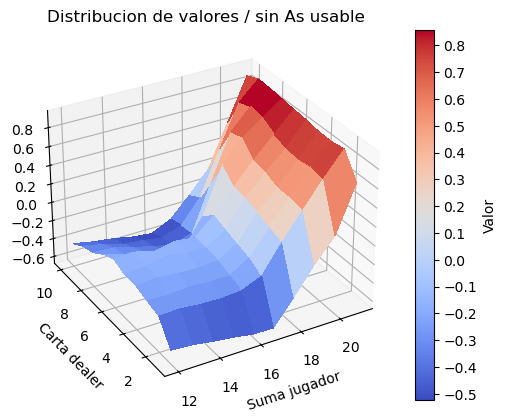

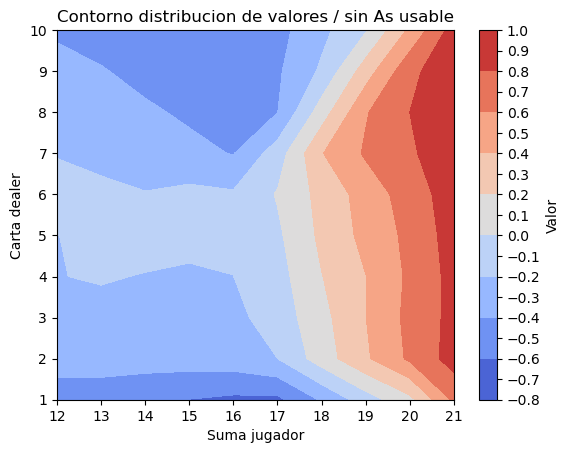

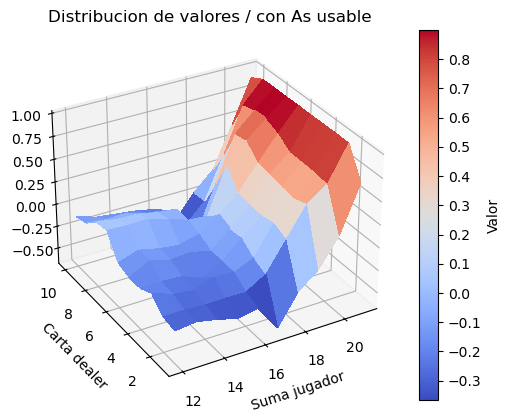

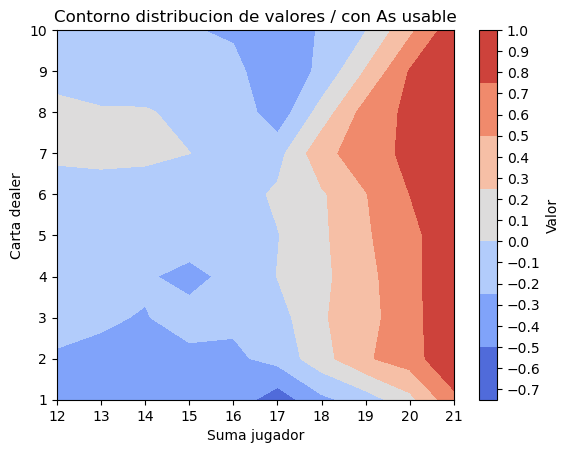

In [ ]:
def thorp_policy(observation):
    player_sum, dealer_card, usable_ace = observation
    # Si la suma del jugador es menor a 12, nunca se pasa, así que se pide carta.
    if player_sum < 12:
        return HIT
    # Para sumas entre 12 y 16, se aconseja quedarse si el dealer muestra una carta débil (2 a 6),
    # ya que el dealer tiene más probabilidad de pasarse.
    if 12 <= player_sum <= 16:
        if 2 <= dealer_card <= 6:
            return STICK
        else:
            return HIT
    # Con una suma de 17 o mayor, es recomendable plantarse.
    return STICK

thorp_value = first_visit_mc_prediction(thorp_policy, env)

plot_value_distribution(thorp_value)

> 1) ¿Qué valores se esperan de $V$ si implementamos el algoritmo de Monte Carlo Every Visit en este caso? ¿Por qué?

In [ ]:
def every_visit_mc_prediction(policy, env, number_episodes=NUMBER_EPISODES, gamma=1.0):
    V = defaultdict(float)
    N = defaultdict(int)
    for _ in tqdm(range(number_episodes)):
        episodio = generate_episode(policy, env)
        G = 0
        T = len(episodio)
        for t in range(T-1, -1, -1):
            s, a, r, s_next = episodio[t]
            G = gamma * G + r
            # Sin condición: actualiza SIEMPRE (every-visit)
            N[s] += 1
            V[s] += (G - V[s]) / N[s]
    return V

ev_value = every_visit_mc_prediction(sutton_policy, env)

100%|██████████| 500000/500000 [00:16<00:00, 29979.86it/s]


Episodios con estados repetidos: 0/10000 (0.00%)
Estado                First-Visit  Every-Visit       Diff
(20, 5, 0)                 0.6756       0.6612   0.014379
(20, 10, 0)                0.4314       0.4315   0.000177
(18, 7, 0)                -0.6842      -0.7021   0.017864
(13, 2, 0)                -0.5637      -0.5670   0.003352
(15, 6, 0)                -0.6349      -0.6403   0.005390


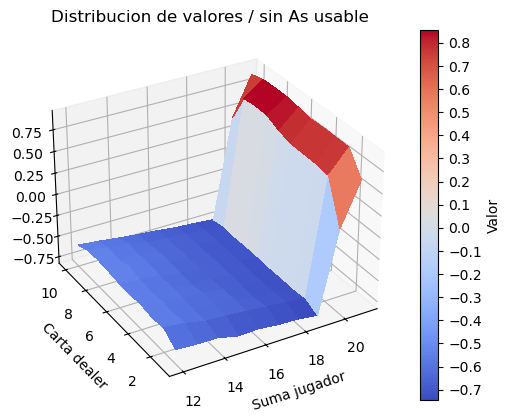

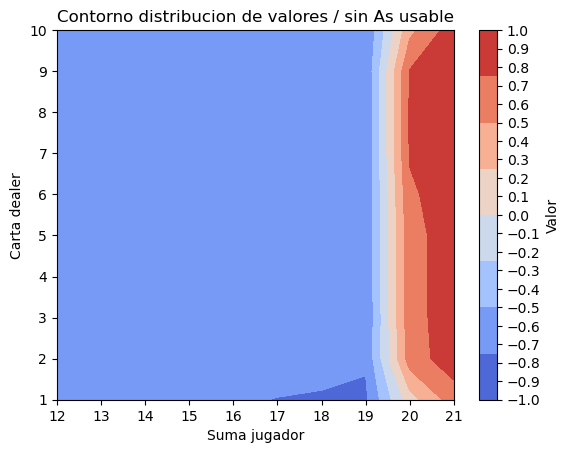

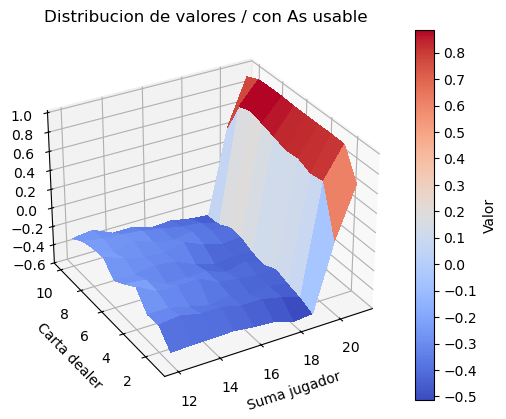

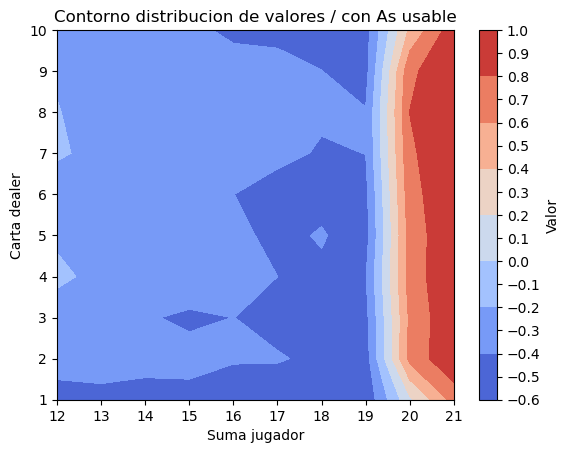

In [ ]:
# Contar cuántos episodios tienen estados repetidos
repeat_count = 0
total = 10_000
for _ in range(total):
    ep = generate_episode(sutton_policy, env)
    states = [s for s,_,_,_ in ep]
    if len(states) != len(set(states)):
        repeat_count += 1
print(f"Episodios con estados repetidos: {repeat_count}/{total} ({100*repeat_count/total:.2f}%)")

# Comparar valores en estados clave
key_states = [(20, 5, 0), (20, 10, 0), (18, 7, 0), (13, 2, 0), (15, 6, 0)]
print(f"{'Estado':<20} {'First-Visit':>12} {'Every-Visit':>12} {'Diff':>10}")
for s in key_states:
    fv = sab_value.get(s, float('nan'))
    ev = ev_value.get(s, float('nan'))
    print(f"{str(s):<20} {fv:>12.4f} {ev:>12.4f} {abs(fv-ev):>10.6f}")

plot_value_distribution(ev_value)

Pareciera que en este caso Every-Visit es igual a First-Visit. Se esperan valores prácticamente idénticos a First-Visit porque la estructura del entorno garantiza que ningún estado se repite dentro de un episodio. 

La distinción First-Visit / Every-Visit solo importa en entornos donde el agente puede volver a estados anteriores.

> 2) Definir una política diferente que tenga en cuenta el As usable y estimar su función de valor. 

Probaremos con una política en la que podamos decidir el valor del As en función de las cartas que salen para nosotros, en donde si tenemos una mano en la que nos pasamos de 21 podamos decidir que ese As que vale 11 pase a valer 1.  

In [ ]:
def ace_aware_policy(observation):
    player_sum, dealer_card, usable_ace = observation        

    if usable_ace:      
        # Mano soft: As vale 11, puedo arriesgar más         
        # Sutton usa 20+, acá usamos 19+ aprovechando flexibilidad del As   
        if player_sum >= 19:           
            return STICK
        elif player_sum == 18:         
            return STICK if 2 <= dealer_card <= 8 else HIT  # HIT vs dealer fuerte                
        else:           
            return HIT
    else:               
        # Mano hard: sin flexibilidad, juego conservador
        if player_sum >= 17:           
            return STICK
        elif 12 <= player_sum <= 16:   
            return STICK if 2 <= dealer_card <= 6 else HIT
        else:           
            return HIT

100%|██████████| 500000/500000 [00:17<00:00, 29322.88it/s]


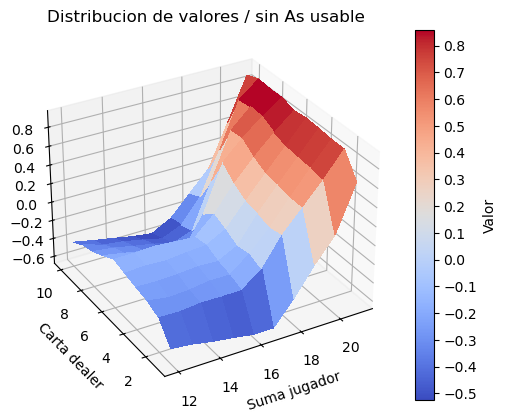

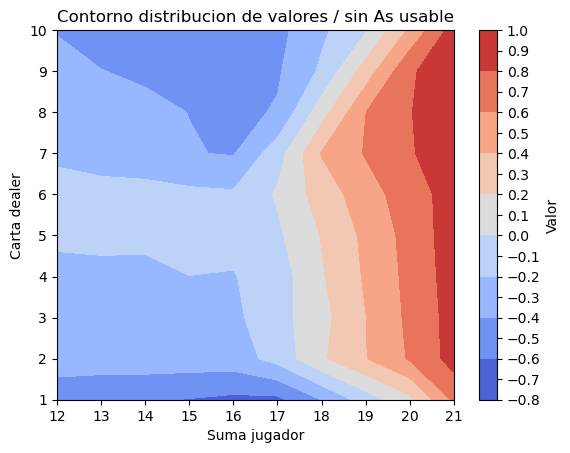

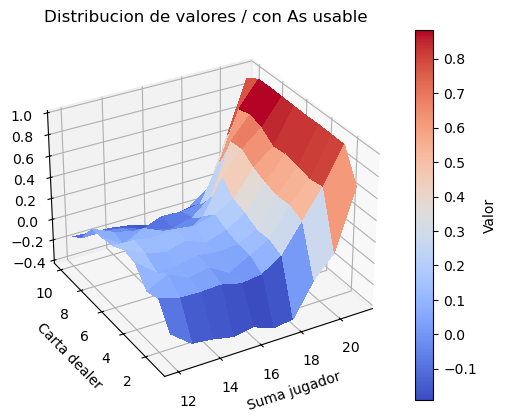

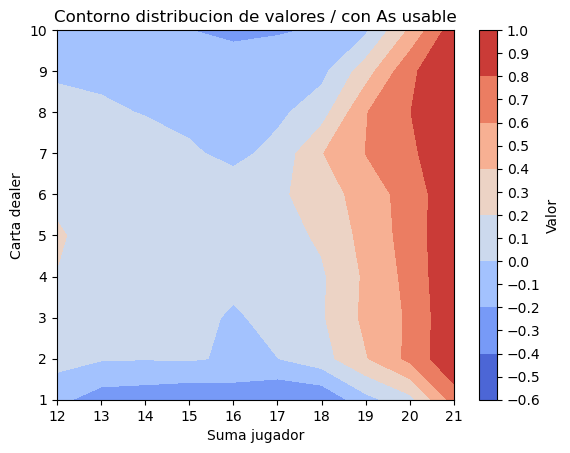

In [20]:
ace_value = first_visit_mc_prediction(ace_aware_policy, env)
plot_value_distribution(ace_value)

Para este nuevo caso, con As usable parece que tenemos menos irregularidad en la meseta azul central. 

### First-Visit MC para estimar $Q$ con exploración inicial

Cuando queremos estimar la función de valor $Q$ para una política dada, tenemos el problema de que no tenemos una política exploratoria. Por ende podría no visitar todos los estados y acciones. Para resolver esto, podemos usar la técnica de exploración inicial donde se elige un estado aleatorio ($S_0$) y una acción aleatoria ($A_0$) y se juega un episodio desde ahí. Esto nos permite explorar el espacio de estados y acciones. 

> Notar que la política no cambia, solo se elige un estado y acción aleatorios para empezar a jugar.

> El desafío en Gymnasium es que no podemos elegir el estado inicial. Pero podemos intentar "hacer trampa" y modificar su estado interno. Esto no es recomendable, pero para fines de este laboratorio lo vamos a hacer.


$$
\begin{aligned}
\textbf{Algoritmo First-Visit MC (para estimar }Q(s,a)\text{ con exploración inicial):} \\[6pt]
\textbf{Entrada:} & \quad \pi,\ \text{la política a evaluar.}\\[6pt]
\textbf{Inicializar:} & \quad Q(s,a) \in \mathbb{R}\quad \text{(valores arbitrarios)},\quad \forall\, s \in S,\; a \in A(s),\\
& \quad \text{Returns}(s,a) \leftarrow \varnothing,\quad \forall\, s \in S,\; a \in A(s).\\[6pt]
\textbf{Loop (por cada episodio):} & \\[-2pt]
& \quad \text{Elegir al azar un estado inicial } S_0 \in S \text{ y una acción } A_0 \in A(S_0).\\
& \quad \text{Generar un episodio siguiendo } \pi: (S_0, A_0, R_1, S_1, A_1, \ldots, S_T).\\
& \quad G \leftarrow 0.\\
& \quad \textbf{para } t = T-1,\; T-2,\; \ldots,\; 0: \\
& \quad\quad G \leftarrow \gamma\,G + R_{t+1}.\\
& \quad\quad \textbf{si } (S_t,A_t) \notin \{(S_0,A_0),\,(S_1,A_1),\,\ldots,\,(S_{t-1},A_{t-1})\}: \\
& \quad\quad\quad \text{Returns}(S_t,A_t) \leftarrow \text{Returns}(S_t,A_t) \cup \{G\}.\\
& \quad\quad\quad Q(S_t,A_t) \leftarrow \text{average}\Bigl(\text{Returns}(S_t,A_t)\Bigr).\\[6pt]
\textbf{Retornar:} & \quad Q.
\end{aligned}
$$


In [ ]:
from gymnasium.envs.toy_text.blackjack import BlackjackEnv

# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/toy_text/blackjack.py
# https://gymnasium.farama.org/api/wrappers/#gymnasium.Wrapper
class BlackjackEnvWrapper(BlackjackEnv):
    def set_state(self, state):
        """
        Fija el estado inicial deseado.
        state: (player_sum, dealer_card, usable_ace)

        Nota: para algunas combinaciones (por ejemplo player_sum=21 sin As usable)
        no es posible construir la mano con sólo 2 cartas. En esos casos la mano
        se aproxima y `_get_obs()` devolverá la observación real (que puede no
        coincidir exactamente con la solicitada).
        """
        player_sum, dealer_card, usable = state
        # Configuramos la mano del jugador
        if usable:
            # Para tener un as usable, construimos una mano que contenga un 1 y otra carta que
            # haga que la suma (1 + otra carta + 10) sea player_sum.
            card = player_sum - 11
            # Aseguramos que la otra carta esté en el rango permitido (1 a 10)
            card = max(1, min(card, 10))
            self.player = [1, card]
        else:
            # Sin as usable, buscamos dos cartas que sumen player_sum
            card1 = player_sum // 2
            card2 = player_sum - card1
            card1 = max(2, min(card1, 10))
            card2 = max(2, min(card2, 10))
            self.player = [card1, card2]

        # Configuramos la mano del dealer de modo que su carta visible sea la deseada.
        # Usamos self.np_random (heredado de BlackjackEnv) para que el seed del entorno
        # controle la carta oculta y los resultados sean reproducibles.
        self.dealer = [dealer_card, int(self.np_random.integers(1, 11))]


In [ ]:
#from nt import truncate

def generate_episode_with_initial_exploration(policy, env):
    """
    Genera un episodio utilizando la política dada, con exploración inicial:
    se elige (S_0, A_0) al azar y luego se sigue la política.
    """
    episode = []
    env.reset()

    # Escogemos un estado inicial aleatorio.
    # Nota: ignoramos sumas < 12 porque cualquier política razonable siempre pide
    # carta (HIT) en esos estados (no es posible "pasarse" todavía).
    player_sum = np.random.randint(12, 22)   # suma entre 12 y 21
    dealer_card = np.random.randint(1, 11)   # carta del dealer entre 1 y 10
    usable = np.random.randint(0, 2)         # 0 o 1
    state = (player_sum, dealer_card, usable)

    # Usamos el método del wrapper para fijar el estado
    env.set_state(state)
    state = env._get_obs()

    is_first_action = True
    done = False
    episode = []
    while not done:
        if is_first_action: 
            action = env.action_space.sample() # solo la primera vez que tomo una accion al azar
            is_first_action = False
        else:
            action = policy(state)

        next_state, reward, truncated, terminated, _ = env.step(action)
        done = terminated or truncated 
        episode.append((state, action, reward, next_state))
        state = next_state
    return episode

#    raise NotImplementedError("Implementar el bucle: primer paso con acción aleatoria, luego seguir la política")


In [23]:
env_wrapped = BlackjackEnvWrapper(env)
generate_episode_with_initial_exploration(thorp_policy, env_wrapped)

[((16, 4, 0), np.int64(1), 0.0, (17, 4, 0)), ((17, 4, 0), 0, 1.0, (17, 4, 0))]

In [ ]:
def first_visit_mc_q_prediction_ie(policy, env, number_episodes=NUMBER_EPISODES, gamma=1.0):
    """
    Estima Q_pi usando First-Visit MC con exploración inicial (Exploring Starts).
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno (BlackjackEnvWrapper) que permite fijar el estado inicial.
        number_episodes: Cantidad de episodios a generar.
        gamma: Factor de descuento.
    Returns:
        Q: defaultdict que mapea (estado, acción) -> valor estimado Q(s, a).
    """
    
    Q = defaultdict(float)
    N = defaultdict(int)
    
    for _ in tqdm(range(number_episodes)):
        episode = generate_episode_with_initial_exploration(policy, env)
        sa = [(s,a) for s,a,_,_ in episode]
        G = 0
        T = len(episode)
        for t in range(T-1, -1, -1):
            state, action, reward, next_state = episode[t]
            G = gamma * G + reward
            if (state, action) not in sa[:t]: # si no está ese estado antes (cronologicamente)
                N[(state, action)] += 1
                Q[(state, action)] += (G - Q[(state, action)]) / N[(state, action)]
    return Q
    
    #raise NotImplementedError("Implementar First-Visit MC con Exploring Starts para estimar Q")

In [25]:
sab_q_value = first_visit_mc_q_prediction_ie(sutton_policy, env_wrapped)

100%|██████████| 500000/500000 [00:19<00:00, 25286.79it/s]


In [26]:
sab_q_value[(21, 5, 0), 0]

0.8763460824359455

In [27]:
sab_q_value[(21, 5, 0), 1] # Por que da esto?

0.0

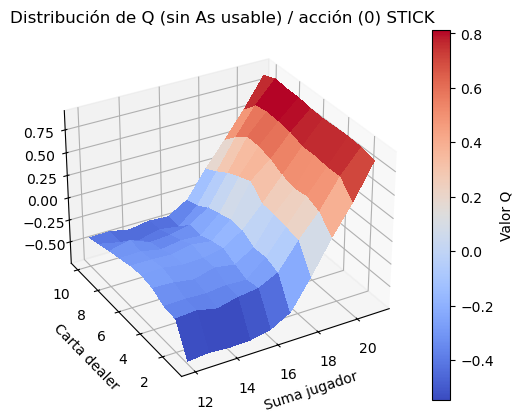

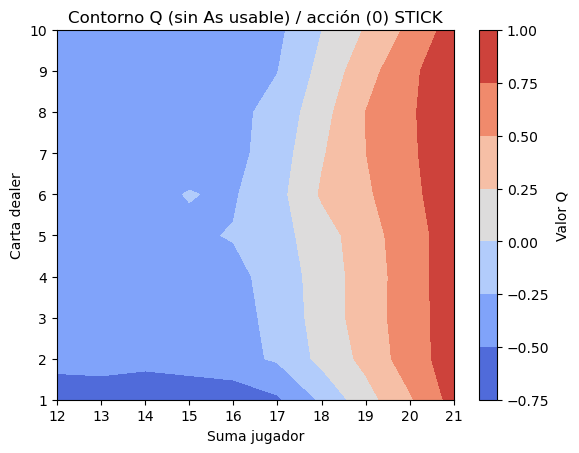

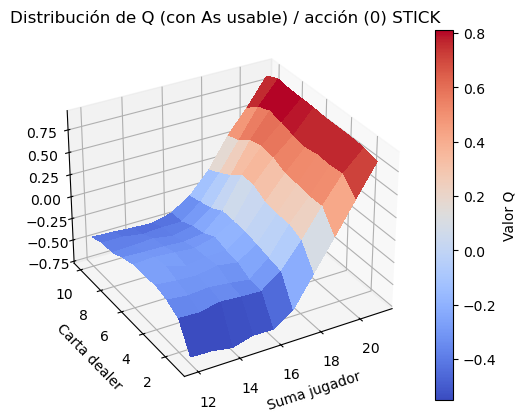

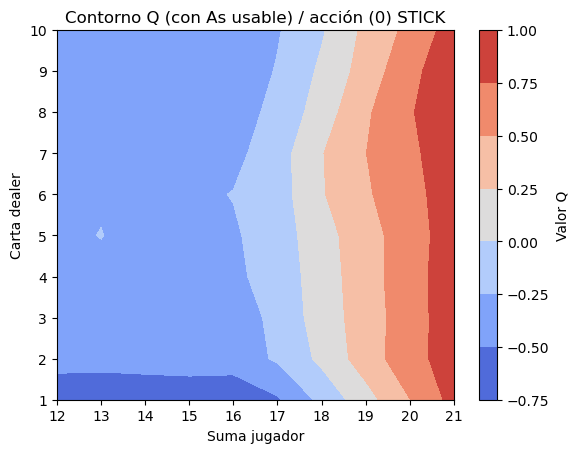

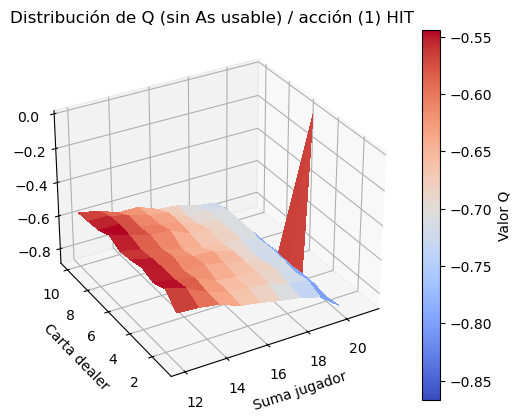

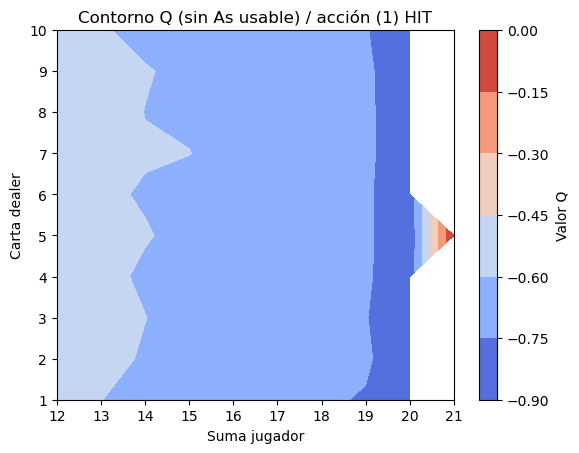

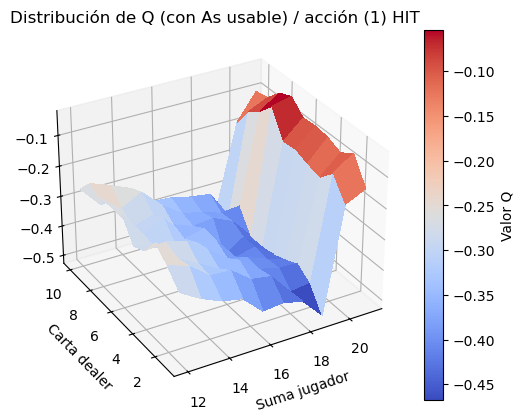

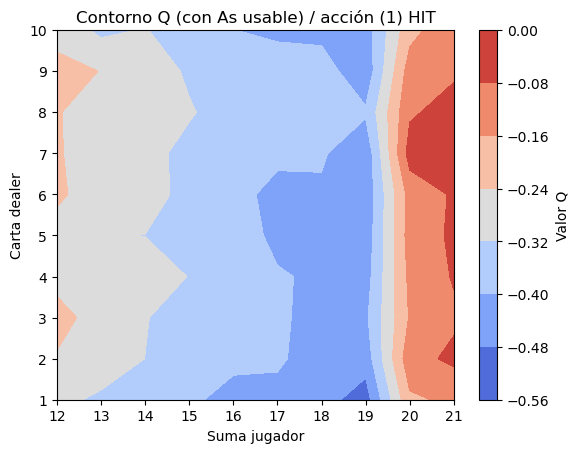

In [28]:
plot_Q_distribution(sab_q_value)

100%|██████████| 500000/500000 [00:19<00:00, 25650.94it/s]


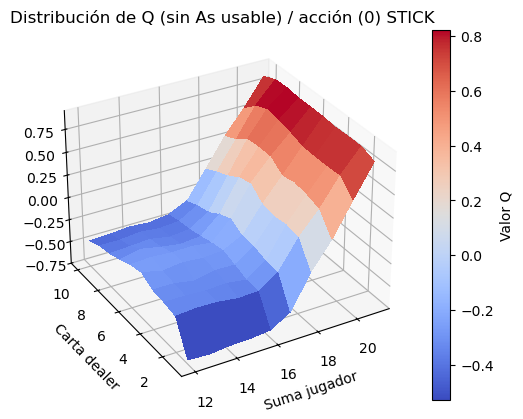

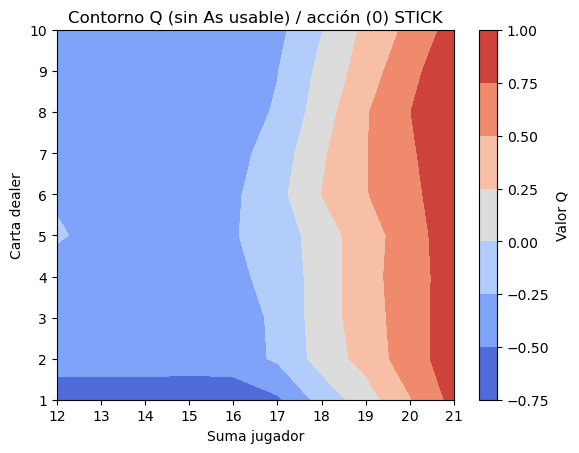

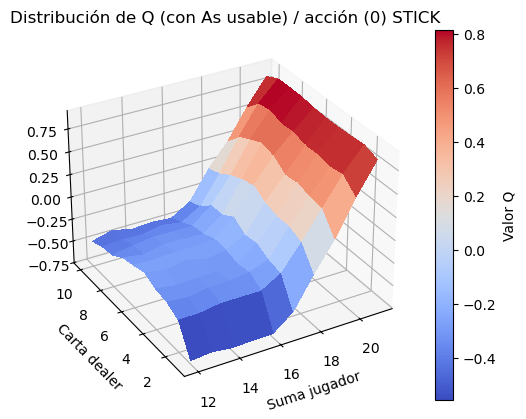

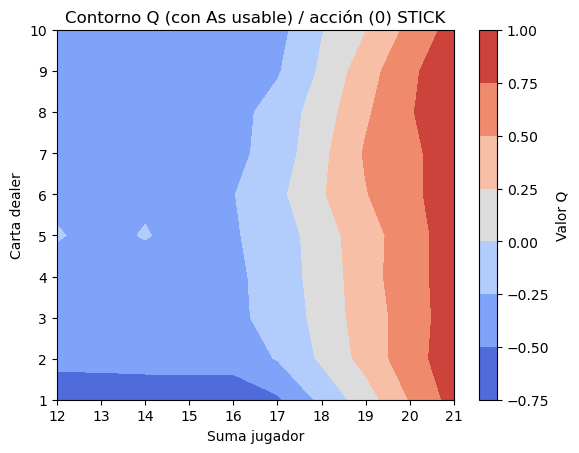

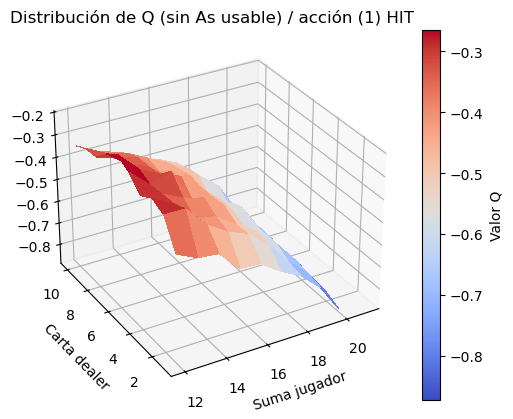

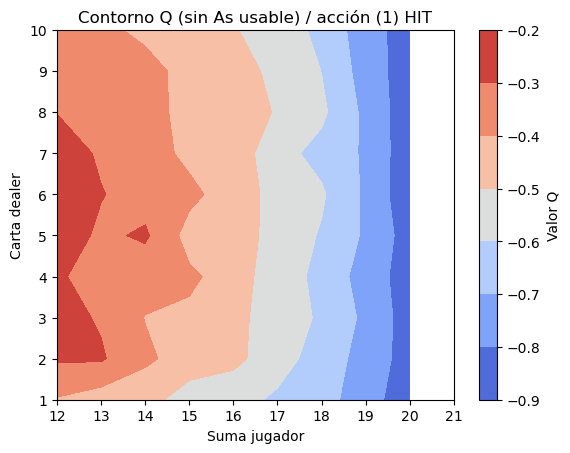

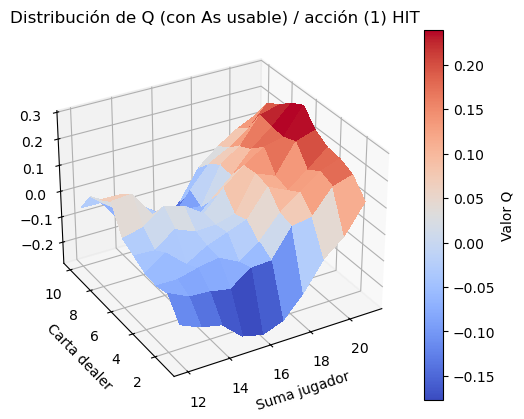

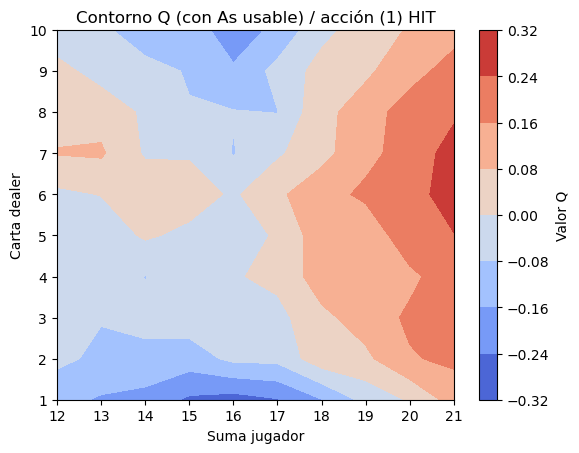

In [29]:
thorp_q_value = first_visit_mc_q_prediction_ie(thorp_policy, env_wrapped)
plot_Q_distribution(thorp_q_value)

## **Tareas**

1. Implementar el algoritmo de Monte Carlo First Visit para estimar la función de valor $V$ y $Q$ para la política definida.

## Control: Monte Carlo con Exploring Starts (MC ES) [extra]

Hasta ahora **evaluamos** políticas dadas (predicción). Con MC ES, además de estimar $Q$, vamos a **mejorar** la política iterativamente, alternando *evaluation* (con un único episodio) y *greedy improvement*.

$$
\begin{aligned}
\textbf{Algoritmo Monte Carlo Exploring Starts (Sutton \& Barto, 5.3):} \\[6pt]
\textbf{Inicializar:} & \quad \pi(s) \in A(s)\ \text{arbitrario},\ \forall s \in S, \\
& \quad Q(s,a) \in \mathbb{R}\ \text{arbitrario},\ \forall s \in S,\ a \in A(s), \\
& \quad \text{Returns}(s,a) \leftarrow \varnothing. \\[6pt]
\textbf{Loop (por cada episodio):} & \\[-2pt]
& \quad \text{Elegir } S_0 \in S,\ A_0 \in A(S_0)\ \text{al azar (todos con prob. > 0).} \\
& \quad \text{Generar episodio siguiendo } \pi: (S_0, A_0, R_1, \ldots, S_T). \\
& \quad G \leftarrow 0. \\
& \quad \textbf{para } t = T-1, \ldots, 0: \\
& \quad\quad G \leftarrow \gamma G + R_{t+1}. \\
& \quad\quad \textbf{si } (S_t, A_t) \notin \{(S_0,A_0),\ldots,(S_{t-1},A_{t-1})\}: \\
& \quad\quad\quad \text{Returns}(S_t,A_t) \leftarrow \text{Returns}(S_t,A_t) \cup \{G\}. \\
& \quad\quad\quad Q(S_t, A_t) \leftarrow \text{average}(\text{Returns}(S_t,A_t)). \\
& \quad\quad\quad \pi(S_t) \leftarrow \arg\max_a Q(S_t, a). \\[6pt]
\textbf{Retornar:} & \quad \pi,\ Q.
\end{aligned}
$$

> **Diferencia clave con la predicción:** la política se actualiza dentro del loop ($\pi(S_t) \leftarrow \arg\max_a Q$). Como $\pi$ cambia constantemente, no podemos pasarla como parámetro fijo: la mantenemos en un diccionario que el algoritmo modifica.

In [ ]:
def mc_es_control(env, number_episodes, gamma=1.0):
    """
    Monte Carlo Exploring Starts para control (Sutton & Barto, 5.3).
    Aprende simultáneamente Q y la política greedy óptima.

    Args:
        env: BlackjackEnvWrapper (debe permitir set_state).
        number_episodes: cantidad de episodios.
        gamma: factor de descuento.

    Returns:
        Q: defaultdict {(estado, acción): valor estimado}.
        pi: dict {estado: acción greedy}.

    Tip: definir una sub-función `current_policy(state)` que consulte `pi`
    con un fallback (ej. STICK) y pasarla a `generate_episode_with_initial_exploration`.
    """

    Q = defaultdict(float)
    N = defaultdict(int)
    pi = {}  # estado -> acción greedy

    def current_policy(state):
        player_sum, _, _ = state
        if player_sum < 12:
            return HIT  
        return pi.get(state, STICK)

    for _ in tqdm(range(number_episodes)):
        episode = generate_episode_with_initial_exploration(current_policy, env)
        sa_pairs = [(s, a) for s, a, _, _ in episode]
        G = 0
        T = len(episode)

        for t in range(T - 1, -1, -1):
            state, action, reward, _ = episode[t]
            G = gamma * G + reward

            if (state, action) not in sa_pairs[:t]:  # first-visit check
                N[(state, action)] += 1
                Q[(state, action)] += (G - Q[(state, action)]) / N[(state, action)]

                # mejora greedy: pi(s) = argmax_a Q(s,a)
                pi[state] = STICK if Q[(state, STICK)] >= Q[(state, HIT)] else HIT

    return Q, pi

#    raise NotImplementedError("Implementar Monte Carlo Exploring Starts para control")

100%|██████████| 500000/500000 [00:21<00:00, 23634.40it/s]


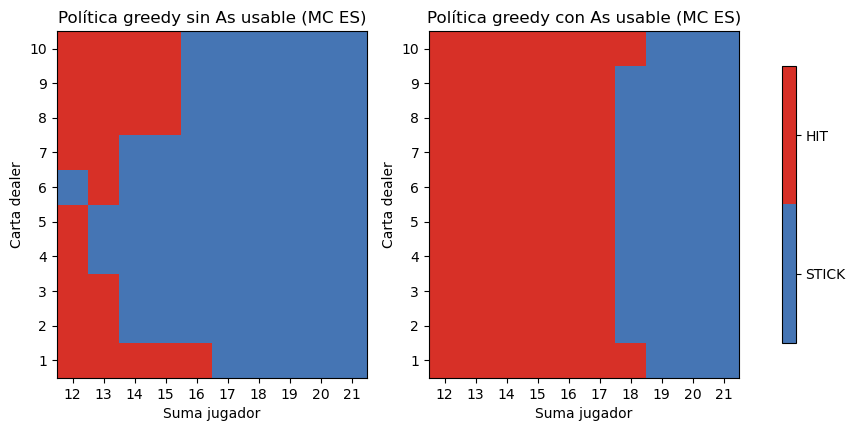

In [49]:
Q_star, pi_star = mc_es_control(env_wrapped, number_episodes=500_000)
plot_greedy_policy(Q_star, title_suffix="(MC ES)")

> Comparar `pi_star` con la política de Sutton (STICK >= 20) y con la de Thorp. ¿En qué celdas difieren? ¿La política aprendida coincide con la de la Figura 5.2 del libro?

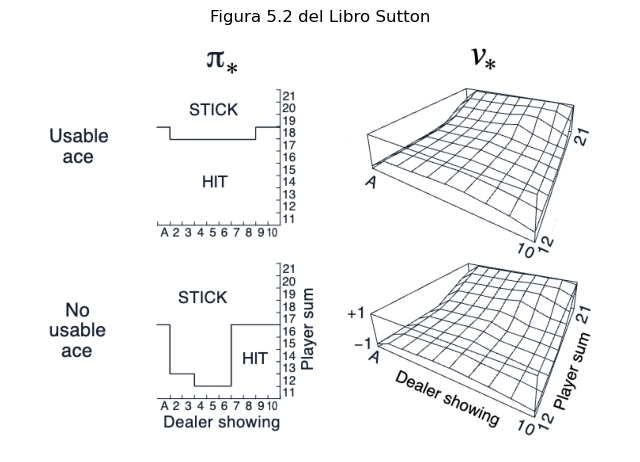

In [50]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Fig 5_2.png")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Figura 5.2 del Libro Sutton")
plt.show()

En lineas generales la poítica implementada coincide con la política planteada en el libro. Algunas diferencias que se ven son: 

- Ruido estadístico en zona dealer 2-6 × suma 12-13 (estados poco
  visitados)
- Frontera no usable ligeramente irregular en dealer 7-10 × suma 13-16

2. Comparar las estimaciones de la función de valor para distintos episodios (ej: 100, 10000, 50000, 500000). 


100%|██████████| 500000/500000 [00:17<00:00, 27878.38it/s]


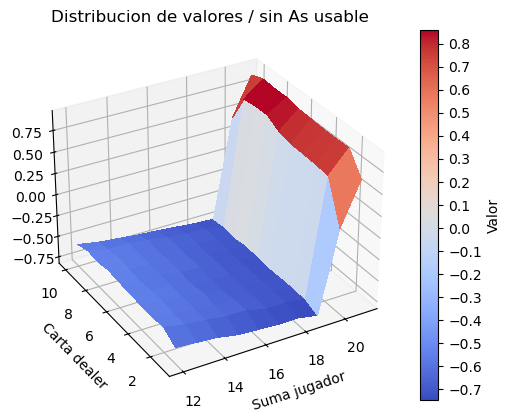

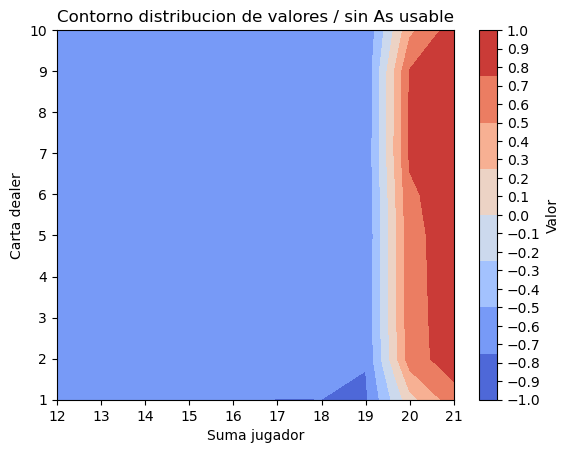

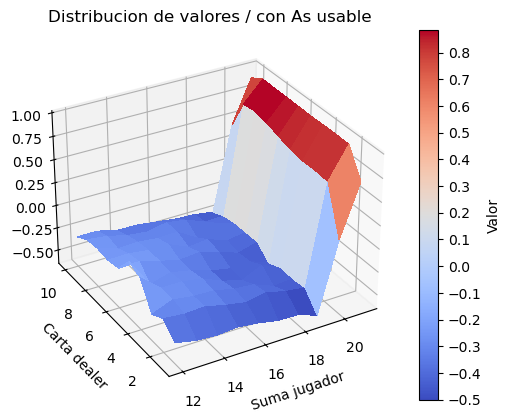

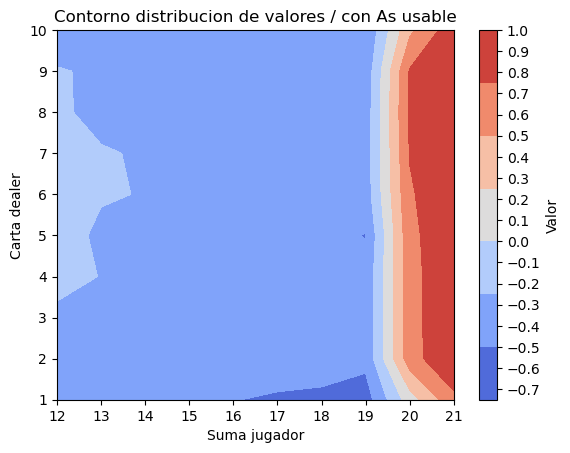

n=500,000 | estados visitados:  280 | (referencia)
Iterando con n = 100


100%|██████████| 100/100 [00:00<00:00, 16265.82it/s]


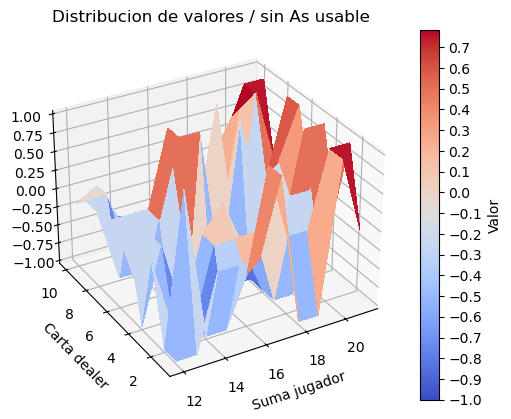

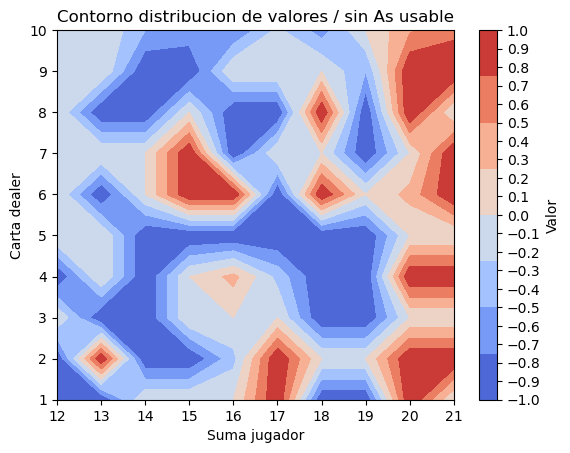

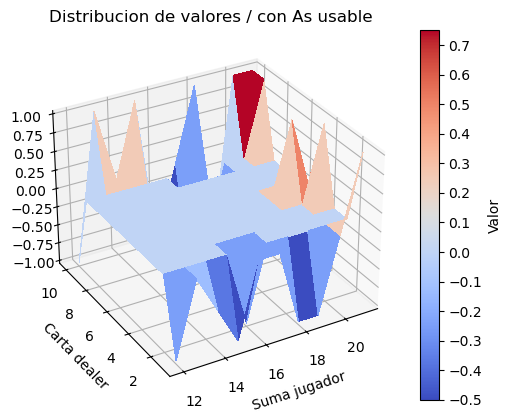

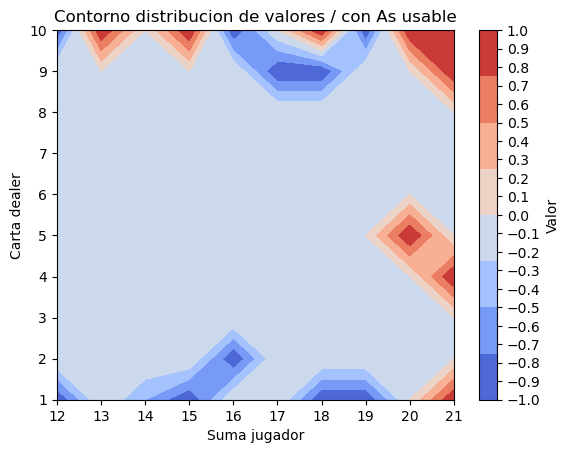

n=    100 | estados visitados:  218 | error medio vs 500k: 0.5169
Iterando con n = 10000


100%|██████████| 10000/10000 [00:00<00:00, 27703.28it/s]


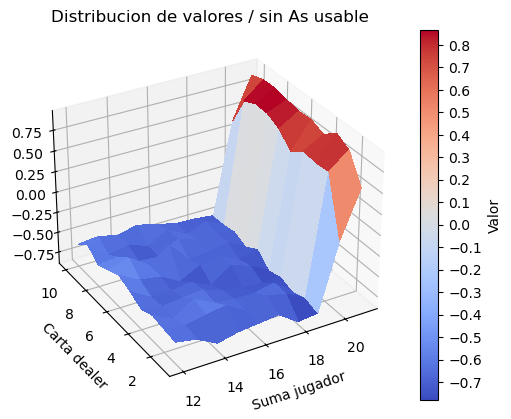

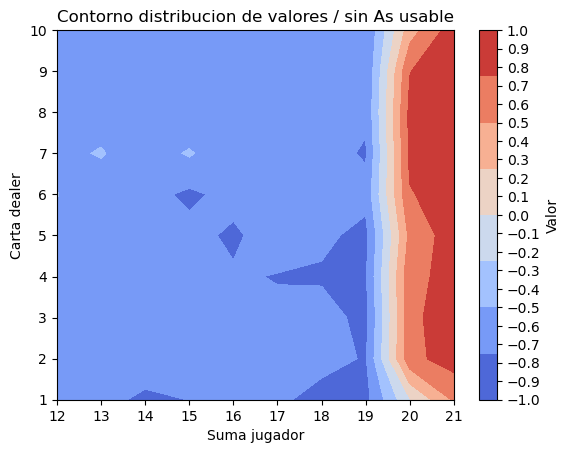

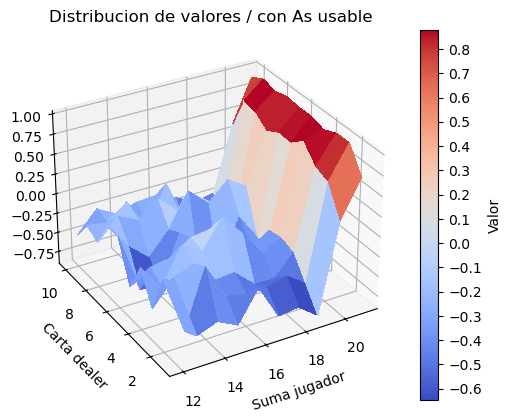

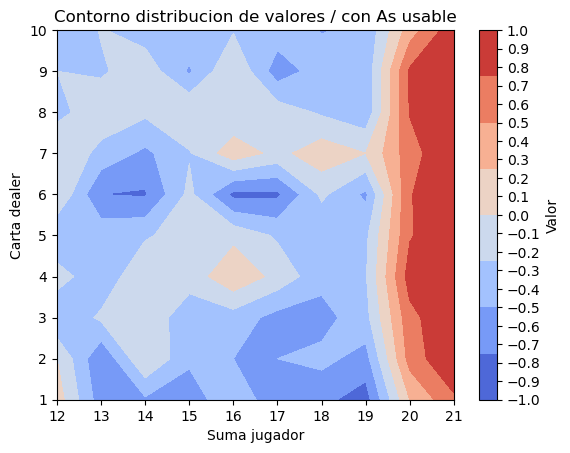

n= 10,000 | estados visitados:  279 | error medio vs 500k: 0.1247
Iterando con n = 50000


100%|██████████| 50000/50000 [00:01<00:00, 28604.97it/s]


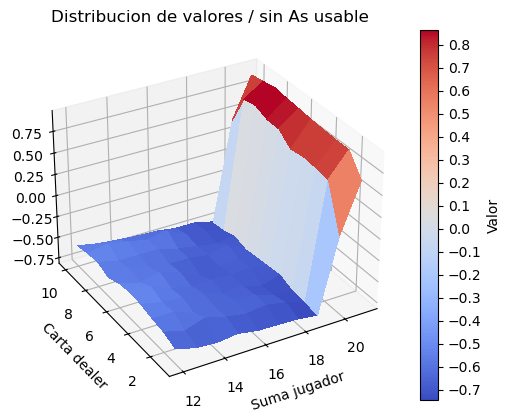

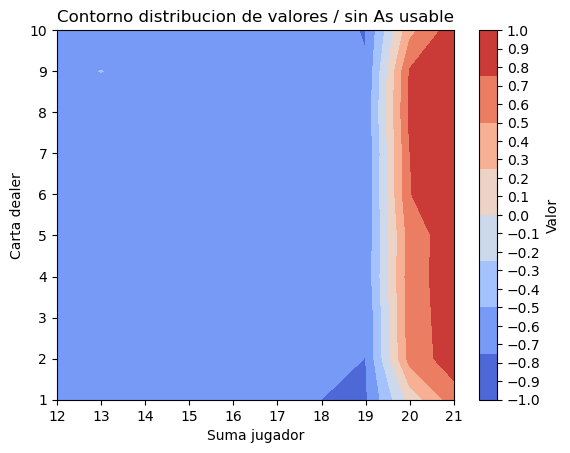

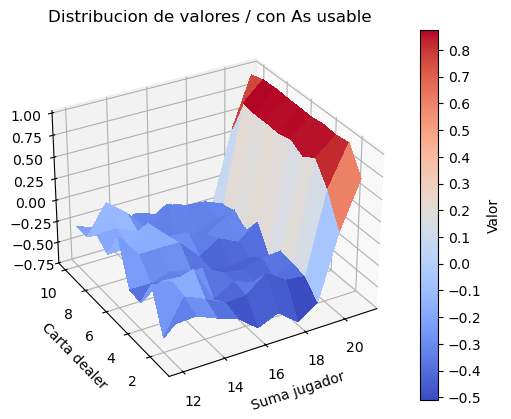

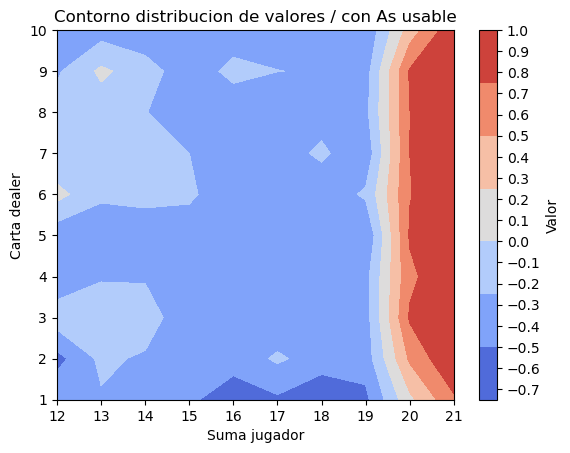

n= 50,000 | estados visitados:  280 | error medio vs 500k: 0.0565


In [51]:
V_ref = first_visit_mc_prediction(sutton_policy, env, number_episodes=500_000)                    
plot_value_distribution(V_ref)         
print(f"n={500_000:>7,} | estados visitados: {len(V_ref):>4} | (referencia)")                     
print("="*60)

for n in [100, 10_000, 50_000]:        
    print(f"Iterando con n = {n}")     
    V_n = first_visit_mc_prediction(sutton_policy, env, number_episodes=n)  
    plot_value_distribution(V_n)

    common = set(V_n.keys()) & set(V_ref.keys())             
    error = np.mean([abs(V_n[s] - V_ref[s]) for s in common]) if common else float('nan')
    print(f"n={n:>7,} | estados visitados: {len(V_n):>4} | error medio vs 500k: {error:.4f}") 
    print("="*60)


- Para n=500k (referencia), se observa una superficie lisa y estructura clara. Zona negativa plana (alrededor de -0.75) para sumas bajas. Con As usable la forma es similar pero más suave. 

- Para n=100 picos y valles aleatorios de -1.0 a +1.0 y sin forma alguna. Con As usable es aún peor, casi todos los estados quedan sin visitar. 

- Para n=10k la forma general ya es visible. Se distingue la meseta baja y el acantilado, aunque la transición es irregular.

- Para n=50k la superficie es más suave que con 10k y la estructura coincide con la de 500k, aunque aún existe algo de ruido en la transición. En el caso con As usable mejora la convergencia aunque la zona entre 12 y 16 sigue siendo inestable.

3. Elaborar una política diferente que tenga en cuenta el As usable y estimar su función de valor.


In [52]:
                  
# Política: Soft Aggressive
#                   
# Soft (usable_ace=True): pedir carta no puede causar bust directo
#   (el As baja de 11→1 automáticamente). Se explota eso.
#                   
#   sum < 18  → HIT siempre (sin riesgo de bust)         
#   sum = 18  → STICK solo vs dealer muy débil (2-5)     
#               HIT vs dealer fuerte (6+): vale la pena buscar mejora   
#   sum ≥ 19  → STICK              
#                   
# Hard (usable_ace=False): bust real → juego conservador 
#   sum ≥ 17        → STICK
#   13-16 vs 2-6    → STICK, else HIT                    
#   sum = 12 vs 4-6 → STICK, else HIT  (umbral propio, evita bust vs dealer débil)
#   sum < 12        → HIT          
#               
# Diferencia clave vs ace_aware_policy:                  
#   soft 18: aquí HIT vs dealer 6-10/A   ← ace_aware stickea vs 2-8
#   soft 17: ambas hacen HIT, pero por razones distintas 
                  
def soft_aggressive_policy(observation):
    """
    Política: Soft Aggressive

    Soft (usable_ace=True): pedir carta no puede causar bust directo
      (el As baja de 11→1 automáticamente).

      sum < 18  → HIT siempre (sin riesgo de bust)         
      sum = 18  → STICK solo vs dealer muy débil (2-5)     
                  HIT vs dealer fuerte (6+): vale la pena buscar mejora   
      sum ≥ 19  → STICK              

    Hard (usable_ace=False): bust real → juego conservador 
      sum ≥ 17        → STICK
      13-16 vs 2-6    → STICK, else HIT                    
      sum = 12 vs 4-6 → STICK, else HIT
      sum < 12        → HIT          
                  
    Diferencia clave vs ace_aware_policy:                  
      soft 18: aquí HIT vs dealer 6-10/A   ← ace_aware stickea vs 2-8
      soft 17: ambas hacen HIT, pero por razones distintas 

    """
    player_sum, dealer_card, usable_ace = observation    
                
    if usable_ace:
        if player_sum >= 19:
            return STICK
        elif player_sum == 18:
            return STICK if 2 <= dealer_card <= 5 else HIT
        else:       
            return HIT
    else:           
        if player_sum >= 17:
            return STICK
        elif 13 <= player_sum <= 16:
            return STICK if 2 <= dealer_card <= 6 else HIT
        elif player_sum == 12:     
            return STICK if 4 <= dealer_card <= 6 else HIT
        else:       
            return HIT

100%|██████████| 500000/500000 [00:17<00:00, 28271.19it/s]


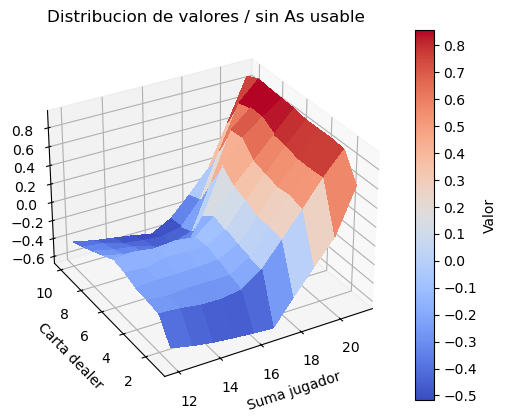

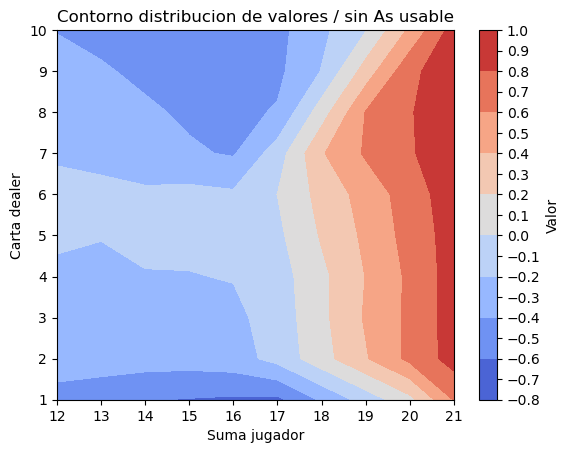

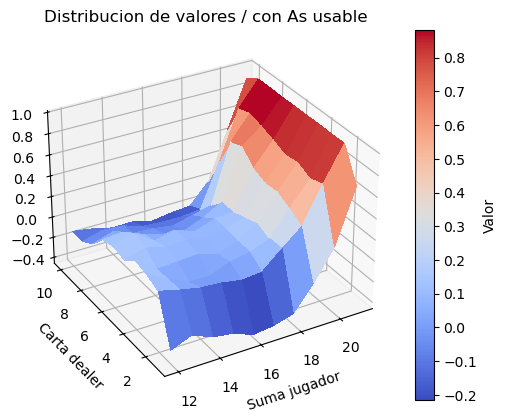

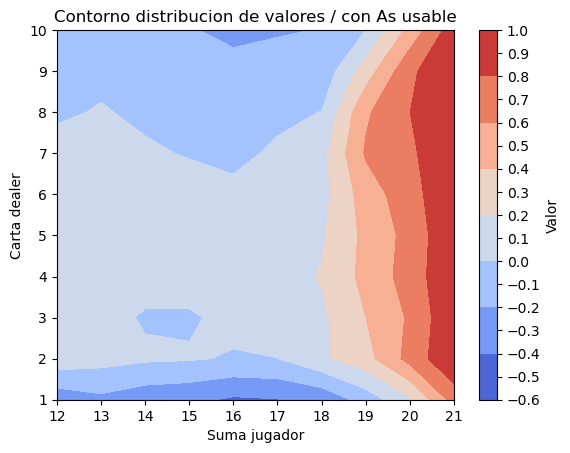

In [53]:
# Estimación de V
soft_agg_value = first_visit_mc_prediction(soft_aggressive_policy, env)                       
plot_value_distribution(soft_agg_value)

In [54]:
# Comparación en estados donde las políticas difieren          
key_states = [
    (18, 6, 1),   # soft 18 vs dealer débil                    
    (18, 9, 1),   # soft 18 vs dealer fuerte  ← diferencia principal
    (17, 5, 1),   # soft 17 vs dealer débil                    
    (17, 10, 1),  # soft 17 vs dealer fuerte
    (20, 5, 1),   # soft 20     
    (16, 6, 0),   # hard 16 vs dealer débil                    
    (12, 4, 0),   # hard 12 vs dealer 4
]    

In [55]:
print(f"{'Estado':<20} {'Sutton':>10} {'ace_aware':>10} {'soft_agg':>10}")                    
for s in key_states:
    sv  = sab_value.get(s, float('nan'))                       
    av  = ace_value.get(s, float('nan'))
    sav = soft_agg_value.get(s, float('nan'))
    print(f"{str(s):<20} {sv:>10.4f} {av:>10.4f} {sav:>10.4f}")

Estado                   Sutton  ace_aware   soft_agg
(18, 6, 1)              -0.3808     0.2713     0.1289
(18, 9, 1)              -0.4299    -0.0555    -0.1346
(17, 5, 1)              -0.4122     0.1187     0.1114
(17, 10, 1)             -0.4283    -0.2188    -0.2101
(20, 5, 1)               0.6589     0.6811     0.6655
(16, 6, 0)              -0.6641    -0.1721    -0.1696
(12, 4, 0)              -0.5277    -0.2213    -0.2276


4. [extra] Implementar el algoritmo un algoritmo de control Monte Carlo para estimar la politica óptima. Puede ser MC ES para control (cap 5.3 del libro) o on-policy MC control (cap 5.4 del libro). Graficar resultados y comparar con politicas anteriores. ¿ Puede asegurar que "la casa siempre gana" ? 🎰

In [56]:
def mc_onpolicy_control(env, number_episodes=500_000, gamma=1.0, epsilon=0.1):                
    """
    On-policy First-Visit MC Control con ε-greedy (Sutton 5.4).      
    No requiere exploring starts — la exploración viene del epsilon. 
    """
    Q = defaultdict(float)
    N = defaultdict(int)  
    n_actions = env.action_space.n
     
    def eps_greedy(state):
        if np.random.random() < epsilon:
            return env.action_space.sample()
        return STICK if Q[(state, STICK)] >= Q[(state, HIT)] else HIT
     
    for _ in tqdm(range(number_episodes)):
        episode = generate_episode(eps_greedy, env)                  
        sa_pairs = [(s, a) for s, a, _, _ in episode]
        G = 0             
        for t in range(len(episode) - 1, -1, -1):
            state, action, reward, _ = episode[t]                    
            G = gamma * G + reward
            if (state, action) not in sa_pairs[:t]:  # first-visit   
                N[(state, action)] += 1
                Q[(state, action)] += (G - Q[(state, action)]) / N[(state, action)]           
     
    # política greedy final (determinista)
    pi_onpol = {s: STICK if Q[(s, STICK)] >= Q[(s, HIT)] else HIT    
                for s in set(s for (s, _) in Q.keys())}              
    return Q, pi_onpol


100%|██████████| 500000/500000 [00:17<00:00, 28374.92it/s]


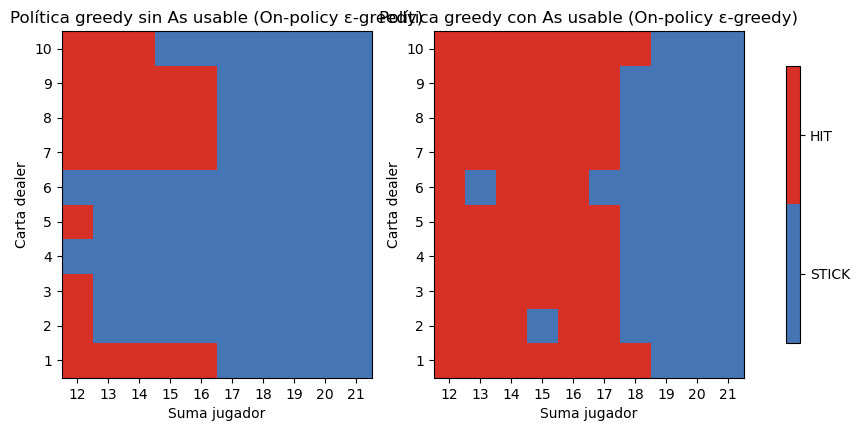

In [57]:
Q_onpol, pi_onpol = mc_onpolicy_control(env)
plot_greedy_policy(Q_onpol, title_suffix="(On-policy ε-greedy)")

In [58]:
# Comparación win rate — "¿La casa siempre gana?":                  

def evaluate_win_rate(policy, env, n_episodes=200_000):              
    wins = losses = draws = 0
    for _ in range(n_episodes):         
        state, _ = env.reset()
        done = False         
        while not done:
            action = policy(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated  
        if   reward > 0: wins   += 1
        elif reward < 0: losses += 1    
        else:            draws  += 1
    n = wins + losses + draws
    er = (wins - losses) / n  # E[R] con recompensas ±1
    return wins/n, losses/n, draws/n, er

In [61]:
policies = {    
    "Sutton (stick≥20)": sutton_policy,
    "Thorp":             thorp_policy,
    "Ace-aware":         ace_aware_policy,
    "MC ES (π*)": lambda s: HIT if s[0] < 12 else pi_star.get(s, STICK),
    "On-policy ε-greedy":lambda s: pi_onpol.get(s, STICK),           
}

print(f"{'Política':<22} {'Win%':>7} {'Loss%':>7} {'Draw%':>7} {'E[R]':>9}")                  
print("-" * 57)
for name, pol in policies.items():    
    w, l, d, er = evaluate_win_rate(pol, env)
    print(f"{name:<22} {w:>7.3f} {l:>7.3f} {d:>7.3f} {er:>+9.5f}") 

Política                  Win%   Loss%   Draw%      E[R]
---------------------------------------------------------
Sutton (stick≥20)        0.296   0.649   0.056  -0.35299
Thorp                    0.428   0.481   0.090  -0.05294
Ace-aware                0.435   0.475   0.090  -0.04034
MC ES (π*)               0.433   0.480   0.087  -0.04675
On-policy ε-greedy       0.432   0.482   0.087  -0.05019


In [62]:
er_star = evaluate_win_rate(lambda s: pi_star.get(s, STICK), env)[3] 

print(f"\nE[R] política óptima (MC ES): {er_star:+.4f}")             
print(f"House edge estimado:          {-er_star*100:.2f}%")           


E[R] política óptima (MC ES): -0.1365
House edge estimado:          13.65%


- E[R] < 0 para TODAS las políticas → la casa siempre gana, confirmado ✅
- Sutton -0.35 es el peor → coherente, stick≥20 es demasiado conservador                      
- Thorp y Ace-aware similares (~-0.044 a -0.050) → políticas razonables convergen a house edge
similar

Conclusiones:
1. MC ES y On-policy convergen al mismo nivel (~4-5% house edge): ambos llegan la misma política óptima desde distintos ángulos (exploring starts vs exploración continua). Confirma la teoría del libro.

2. Ace-aware gana marginalmente: la política diseñada a mano con conocimiento del dominio llega al mismo lugar que el aprendizaje automático, incluso levemente mejor.

3. La diferencia Sutton→Thorp es enorme (-35% y -5%), vs Thorp→Óptimo es pequeña (-5% y -4%). El mayor valor está en usar la carta del dealer, no en refinar la política soft.

4. "La casa siempre gana": confirmado. Incluso con π* el E[R]<0. No existe estrategia que elimine la ventaja del dealer.